# Annotated fields: correct, wrong or missed

For one run and one sample, every field the person annotated is checked against what each
model wrote at the same place:

| Outcome | Meaning |
|---|---|
| **Correct** | the model's value matches the annotation |
| **Wrong** | the model wrote a different value there |
| **Missed** | the model wrote nothing there, or left it empty |

Fields the person left empty are not shown. The matrix has one panel per model; each row is
a kind of field, with the number annotated in brackets, and each cell is the share of that
row. The table underneath lists every annotated field.

**To look at another run or sample:** change `RUN` and `SAMPLE` in the next cell.


In [1]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

if Path.cwd().name == "notebooks":
    import os
    os.chdir(Path.cwd().parent)

RUN    = "v4-sample14"                           # a folder under data/output/rda/runs/
SAMPLE = 14
RESULT = Path("data/output/rda/runs") / RUN / "evaluation_results.xlsx"
CHART  = Path("data/output/rda/runs") / RUN / f"field_matrix_sample{SAMPLE}.png"
MODELS = ["llama3.1-8b", "gemma4-e4b", "llama3.3-70b"]
OUTCOMES = ["Correct", "Wrong", "Missed"]

INK, MUTED, SURFACE = "#0b0b0b", "#52514e", "#fcfcfb"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "text.color": INK,
    "axes.titlecolor": INK, "font.size": 10, "axes.titlesize": 12, "axes.titleweight": "bold",
})
pd.set_option("display.max_colwidth", 60)
pd.set_option("display.max_rows", 300)
pd.set_option("display.width", 220)


## 1. One outcome per annotated field and model


In [2]:
details = pd.read_excel(RESULT, sheet_name="details")
if "sample" in details:
    details = details[details["sample"] == SAMPLE]
details["model"] = details["model"].str.replace(":", "-")


def outcome(rows):
    """The evaluation writes one or two rows per annotated field; reduce them to one outcome."""
    if (rows.verdict == "Correct").any():
        return "Correct"
    wrote = rows[(rows.verdict == "Hallucinated") & (rows.reason != "empty where the reference has a value")]
    return "Wrong" if len(wrote) else "Missed"


def kind(path):
    """A readable name for a kind of field: dmp.dataset[3].distribution[0].host.title -> dataset > host > title"""
    p = re.sub(r"\[\d+\]", "", path.replace("dmp.", "", 1))
    return p.replace("distribution.", "").replace(".", " > ").replace("_", " ")


annotated = details[details["reference value"].notna()]
fields = (annotated.groupby(["field", "model"]).apply(outcome, include_groups=False)
          .rename("outcome").reset_index())
fields["kind"] = fields["field"].map(kind)
values = annotated.drop_duplicates("field").set_index("field")["reference value"]
wrote = (annotated[annotated["model value"].notna()]
         .drop_duplicates(["field", "model"]).set_index(["field", "model"])["model value"])

models = [m for m in MODELS if m in set(fields.model)]
n_fields = fields.field.nunique()
print(f"run {RUN}, sample {SAMPLE}: {n_fields} annotated fields, models: {', '.join(models)}")
display(fields.pivot_table(index="model", columns="outcome", values="field", aggfunc="count", fill_value=0)
        .reindex(index=models, columns=OUTCOMES, fill_value=0))


run v4-sample14, sample 14: 135 annotated fields, models: llama3.1-8b, gemma4-e4b, llama3.3-70b


outcome,Correct,Wrong,Missed
model,,,
llama3.1-8b,56,3,76
gemma4-e4b,9,11,115
llama3.3-70b,73,9,53


## 2. The matrix

One row per model, one column per part of the form, with how many fields were annotated in
brackets; the last column is all fields together. Each cell: the share extracted correctly
(also its colour), how many of how many, and how many were wrong or missed. Sized 16:9 for
slides.


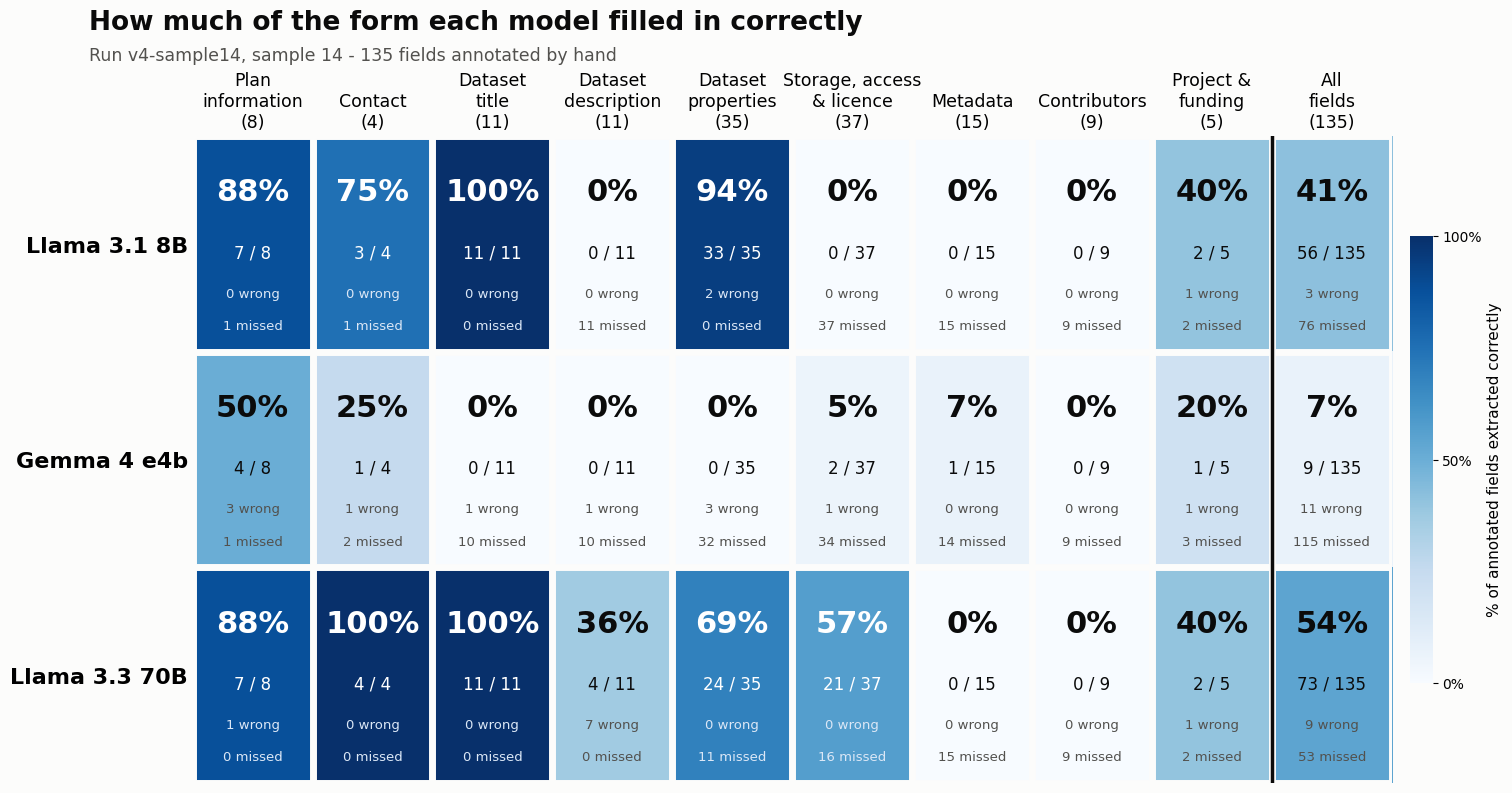

saved -> data\output\rda\runs\v4-sample14\field_matrix_sample14.png


In [3]:
def group(path):
    p = re.sub(r"\[\d+\]", "", path).replace("dmp.", "", 1)
    if p.startswith("dataset."):
        rest = p[len("dataset."):]
        if rest == "title":                return "Dataset title"
        if rest == "description":          return "Dataset description"
        if rest.startswith("distribution"): return "Storage, access & licence"
        if rest.startswith("metadata"):    return "Metadata"
        return "Dataset properties"
    if p.startswith("contact"):            return "Contact"
    if p.startswith("contributor"):        return "Contributors"
    if p.startswith("project"):            return "Project & funding"
    return "Plan information"


GROUPS = ["Plan information", "Contact", "Dataset title", "Dataset description", "Dataset properties",
          "Storage, access & licence", "Metadata", "Contributors", "Project & funding"]
# Every header is two lines of name, so all names sit on the same lines and every count below them
HEADER = {"Plan information": "Plan\ninformation", "Contact": "\nContact", "Dataset title": "Dataset\ntitle",
          "Dataset description": "Dataset\ndescription", "Dataset properties": "Dataset\nproperties",
          "Storage, access & licence": "Storage, access\n& licence", "Metadata": "\nMetadata",
          "Contributors": "\nContributors", "Project & funding": "Project &\nfunding", "All": "All\nfields"}
NAME = {"llama3.1-8b": "Llama 3.1 8B", "gemma4-e4b": "Gemma 4 e4b", "llama3.3-70b": "Llama 3.3 70B"}

fields["group"] = fields["field"].map(group)
n_group = fields.drop_duplicates("field").group.value_counts()
groups = [g for g in GROUPS if g in n_group.index] + ["All"]
n_group["All"] = n_fields
cnt = fields.groupby(["model", "group", "outcome"]).size().unstack(fill_value=0).reindex(columns=OUTCOMES, fill_value=0)


def cell(m, g):
    c = cnt.xs(m, level="model").sum() if g == "All" else (
        cnt.loc[(m, g)] if (m, g) in cnt.index else pd.Series(0, index=OUTCOMES))
    return c, c["Correct"] / n_group[g]


share = np.array([[cell(m, g)[1] for g in groups] for m in models])
fig, ax = plt.subplots(figsize=(16, 2.0 * len(models) + 2.4))
im = ax.imshow(share, cmap="Blues", vmin=0, vmax=1, aspect="auto")
for i, m in enumerate(models):
    for j, g in enumerate(groups):
        c, v = cell(m, g)
        dark = v > 0.55
        ax.text(j, i - 0.24, f"{v:.0%}", ha="center", va="center", fontsize=22, fontweight="bold",
                color="white" if dark else INK)
        ax.text(j, i + 0.04, f"{c['Correct']} / {n_group[g]}", ha="center", va="center", fontsize=12,
                color="white" if dark else INK)
        ax.text(j, i + 0.23, f"{c['Wrong']} wrong", ha="center", va="center", fontsize=9.5,
                color="#dbe7f6" if dark else MUTED)
        ax.text(j, i + 0.38, f"{c['Missed']} missed", ha="center", va="center", fontsize=9.5,
                color="#dbe7f6" if dark else MUTED)

ax.set_xticks(range(len(groups)))
ax.set_xticklabels([f"{HEADER[g]}\n({n_group[g]})" for g in groups], fontsize=12.5)
for lbl in ax.get_xticklabels()[-1:]:
    lbl.set_fontweight("bold")
ax.xaxis.tick_top()
ax.set_yticks(range(len(models)))
ax.set_yticklabels([NAME.get(m, m) for m in models], fontsize=16, fontweight="bold")
ax.set_xticks(np.arange(-.5, len(groups), 1), minor=True)
ax.set_yticks(np.arange(-.5, len(models), 1), minor=True)
ax.grid(which="minor", color=SURFACE, linewidth=5)
ax.tick_params(which="both", length=0)
ax.axvline(len(groups) - 1.5, color=INK, linewidth=2.5)        # separates the total column
for s in ax.spines.values():
    s.set_visible(False)

cbar = fig.colorbar(im, ax=ax, fraction=0.018, pad=0.015)
cbar.outline.set_visible(False)
cbar.set_ticks([0, 0.5, 1.0])
cbar.set_ticklabels(["0%", "50%", "100%"])
cbar.set_label("% of annotated fields extracted correctly", fontsize=11)
fig.text(0.06, 1.0, f"How much of the form each model filled in correctly", fontsize=19, fontweight="bold",
         ha="left", va="bottom")
fig.text(0.06, 0.965, f"Run {RUN}, sample {SAMPLE} - {n_fields} fields annotated by hand", fontsize=12.5,
         color=MUTED, ha="left", va="bottom")
fig.savefig(CHART, dpi=200, bbox_inches="tight", facecolor=SURFACE)
plt.show()
print(f"saved -> {CHART}")


## 3. Every annotated field

One row per field the person annotated: the annotated value, each model's outcome, and,
when it was wrong, what the model wrote instead.


In [4]:
wide = fields.pivot(index="field", columns="model", values="outcome").reindex(columns=models)
wide.insert(0, "annotated value", values.reindex(wide.index).astype(str).str.slice(0, 60))
for m in models:
    wide[f"{m} wrote"] = [str(wrote.get((f, m), ""))[:45] if wide.loc[f, m] == "Wrong" else ""
                          for f in wide.index]
natural = lambda f: [int(x) if x.isdigit() else x for x in re.split(r"(\d+)", f)]
display(wide.loc[sorted(wide.index, key=natural)].reset_index())


model,field,annotated value,llama3.1-8b,gemma4-e4b,llama3.3-70b,llama3.1-8b wrote,gemma4-e4b wrote,llama3.3-70b wrote
0,dmp.contact.affiliation[0].name,Hakai Institute,Missed,Missed,Correct,,,
1,dmp.contact.contact_id[0].identifier,0000-0001-9317-0364,Correct,Wrong,Correct,,0000-0003-0644-4174,
2,dmp.contact.contact_id[0].type,orcid,Correct,Correct,Correct,,,
3,dmp.contact.name,Brett Johnson,Correct,Missed,Correct,,,
4,dmp.contributor[0].name,Brett Johnson,Missed,Missed,Missed,,,
5,dmp.contributor[0].role[0],Principal Investigator,Missed,Missed,Missed,,,
6,dmp.contributor[0].role[1],Data Manager,Missed,Missed,Missed,,,
7,dmp.contributor[1].name,Brian Hunt,Missed,Missed,Missed,,,
8,dmp.contributor[1].role[0],Principal Investigator,Missed,Missed,Missed,,,
9,dmp.contributor[2].name,Tim van der Stap,Missed,Missed,Missed,,,
